# Tabular ML 실습 노트북

이 노트북은 학부생 강의 "Tabular ML"의 실습용 자료입니다.
대표적인 표형식 데이터셋을 활용해 다음 6가지 방법론을 한 번씩 실험해 봅니다.

1. **데이터셋 다운로드** — UCI MAGIC Gamma Telescope (binary classification, 비선형성이 강한 물리 데이터)
2. **Logistic Regression** — 가장 단순한 선형 모델
3. **Decision Tree / XGBoost** — 전통적 비선형 모델, 부스팅 트리
4. **Deep Architecture (TabM)** — MLP 기반 최신 딥러닝 모델
5. **LLM 실험** — 행(row)을 자연어로 직렬화한 뒤 작은 오픈 LLM으로 분류
6. **TabPFN** — Tabular Foundation Model

> **권장 런타임**: Colab GPU (T4) — TabM, LLM, TabPFN 단계에서 GPU 사용 시 훨씬 빠릅니다.
> **메뉴**: `런타임` → `런타임 유형 변경` → `T4 GPU`


## 0. 환경 설정

필요한 패키지를 설치합니다. Colab에는 numpy/pandas/sklearn/torch가 이미 설치되어 있으므로,
추가로 필요한 `xgboost`, `tabpfn`, `transformers`, `accelerate`만 설치합니다.


In [ ]:
# 패키지 설치 (Colab 기준)
# 처음 한 번만 실행하면 됩니다. 설치 후 런타임 재시작이 필요할 수도 있습니다.
!pip install -q uv
!uv pip install \
    "tabpfn==2.0.9" \
    "autogluon" \
    "autogluon.tabular[tabarena]" \
    "openfe"
 #autogluon xgboost, transformers 등을 자동으로 설치
# 기존
#     !pip install -q uv
# !uv pip install \
#     "xgboost>=3.0.0" \
#     "tabpfn==2.0.9" \
#     "transformers>=4.45,<5.0" \
#     "accelerate>=0.34" \
#     "autogluon" \
#     "autogluon.tabular[tabarena]" \
#     "openfe"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 14.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.9/128.9 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 113.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.6/227.6 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 452.1/452.1 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 46.2 MB/s eta 0

In [ ]:
# 공통 import
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch

# 재현성을 위한 시드 고정 ->난수 고정 SEED
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# GPU 사용 가능 여부 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)


device = cuda


## 1. 데이터셋: MAGIC Gamma Telescope

**Task**: 첸코프(MAGIC) 망원경이 관측한 샤워 이미지에서 추출한 10개의
형상/대칭/모멘트 feature를 보고, 그 이벤트가 **감마선 신호(gamma)** 인지
**우주선 하드론 배경(hadron)** 인지 판별하는 binary classification.

- 19,020개 샘플 — gamma 12,332 / hadron 6,688 (대략 65% / 35%)
- Feature 10개 모두 **수치형(continuous)**. 결측치 없음.
- 결정경계가 **강하게 비선형**이라 선형 모델과 비선형 모델의 차이가 잘 드러남
  → 강의에서 "왜 트리/딥러닝이 필요한가" 보여주기에 적합.
- 출처: <https://archive.ics.uci.edu/dataset/159/magic+gamma+telescope>

> *Adult Income 같은 인구통계 데이터는 선형성이 강해 LR이 종종 비등하게 나옵니다.*
> *MAGIC은 물리적 비선형성이 본질적이라 모델 간 차이가 보다 명확히 보입니다.*


In [ ]:
# 1) 데이터 다운로드 — UCI 서버에서 단일 CSV 파일을 직접 받아옵니다.
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.data"

NUM_COLS = [
    "fLength",   # 주축 길이
    "fWidth",    # 부축 너비
    "fSize",     # 픽셀 합의 log
    "fConc",     # 상위 2 픽셀 / fSize
    "fConc1",    # 최상위 픽셀 / fSize
    "fAsym",     # 주축 비대칭도
    "fM3Long",   # 주축 3차 모멘트
    "fM3Trans",  # 부축 3차 모멘트
    "fAlpha",    # 주축과 원점 벡터 사이 각도
    "fDist",     # 원점에서 중심까지 거리
]
TARGET = "class"
COLUMNS = NUM_COLS + [TARGET]

df = pd.read_csv(DATA_URL, header=None, names=COLUMNS)
# 컬럼명 있는 경우
print("shape:", df.shape)
df.head()


shape: (19020, 11)


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [ ]:
# 2) 학습/테스트 분리 (8:2, 클래스 비율 유지)
from sklearn.model_selection import train_test_split

CAT_COLS = []   # MAGIC에는 범주형 feature가 없음 — 변수만 정의해 두기

# 라벨: 'g' (gamma, 신호) → 1, 'h' (hadron, 배경) → 0
df["y"] = (df[TARGET] == "g").astype(int)

train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df["y"], random_state=SEED,
)
print("train:", train_df.shape, "test:", test_df.shape)
print("\n== 타겟 분포 (train) ==")
print(train_df[TARGET].value_counts(normalize=True).round(3))
# 1 타겟 컬럼 꺼내기
# 2 각 값의 비율 계산/normalize=False면 개수로
# 3 소수점 3자리로 반올림


train: (15216, 12) test: (3804, 12)

== 타겟 분포 (train) ==
class
g    0.648
h    0.352
Name: proportion, dtype: float64


In [ ]:
# from autogluon.tabular import TabularPredictor

# predictor = TabularPredictor(label='class')
# predictor.fit(train_df, time_limit=3600)  # 1시간 동안 알아서 다 함
# predictor.predict(test_df)

### 1-1. 전처리

MAGIC은 모두 수치형이라 전처리가 매우 단순합니다.

1. **타겟 인코딩** — `g` (gamma) → 1, `h` (hadron) → 0
2. **선형/딥러닝 모델용** — StandardScaler 적용
3. **트리 모델용** — 원본 그대로 (트리는 스케일 불필요)


In [ ]:
from sklearn.preprocessing import StandardScaler

def split_xy(d):
    return d[NUM_COLS].to_numpy(dtype=float), d["y"].to_numpy()

X_train_raw, y_train = split_xy(train_df)
X_test_raw,  y_test  = split_xy(test_df)

# (A) 트리 모델용: 원본 그대로
X_train_tree = X_train_raw
X_test_tree  = X_test_raw

# (B) 선형/딥러닝 모델용: StandardScaler
scaler = StandardScaler().fit(X_train_raw)
X_train_lin = scaler.transform(X_train_raw)
X_test_lin  = scaler.transform(X_test_raw)

print("Tree 형태  :", X_train_tree.shape, X_test_tree.shape)
print("Linear 형태:", X_train_lin.shape,  X_test_lin.shape)


Tree 형태  : (15216, 10) (3804, 10)
Linear 형태: (15216, 10) (3804, 10)


In [ ]:
# 평가 지표를 한 곳에서 계산하는 헬퍼
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

# 결과를 누적할 딕셔너리
results = {}

def evaluate(name, y_true, y_pred, y_score=None):#기본값이 None
    acc = accuracy_score(y_true, y_pred) #정확도(accuracy):전체 중 예측을(0이든 1이든)맞힌 비율
    f1  = f1_score(y_true, y_pred) #조화평균(2*정밀도*재현도/정밀도+재현도)=>비율끼리의 평균시
    #정밀도(precision): 1이라고 예측한것중 실제 1 비율,재현도(recall): 1인것들중 맞춘 비율
    auc = roc_auc_score(y_true, y_score) if y_score is not None else float("nan") #삼항연산자
    results[name] = {"Accuracy": acc, "F1": f1, "AUC": auc}
    print(f"[{name}] Accuracy={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")


## **Autogluon** **사용해보기**

In [ ]:

from autogluon.tabular import TabularPredictor

train_df_ag = train_df.drop(columns=['y'])
test_df_ag  = test_df.drop(columns=['y'])

predictor = TabularPredictor(label='class', eval_metric='roc_auc')
predictor.fit(train_df_ag, time_limit=300)


y_pred_ag     = predictor.predict(test_df_ag)
y_score_ag    = predictor.predict_proba(test_df_ag)['g']
y_pred_ag_bin = (y_pred_ag == 'g').astype(int)

evaluate("AutoGluon", y_test, y_pred_ag_bin, y_score_ag)
predictor.leaderboard(silent=True) #쓸데 없는 로그를 줄여주고 표를 예쁘게 보여준다.

No path specified. Models will be saved in: "AutogluonModels/ag-20260709_014914"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.56/14.56 GB
Total GPU Memory:   Free: 14.56 GB, Allocated: 0.00 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       9.12 GB / 12.67 GB (72.0%)
Disk Space Avail:   58.69 GB / 112.64 GB (52.1%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : New in v1.5: The state-of-the-art for tabular data. Massively better t

[1000]	valid_set's binary_logloss: 0.291692


	0.9361	 = Validation score   (roc_auc)
	6.4s	 = Training   runtime
	0.22s	 = Validation runtime
Fitting model: LightGBM ... Training model for up to 293.04s of the 293.04s of remaining time.
	Fitting with cpus=1, gpus=0, mem=0.0/9.0 GB
	0.9312	 = Validation score   (roc_auc)
	1.79s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestGini ... Training model for up to 291.16s of the 291.16s of remaining time.
	Fitting with cpus=2, gpus=0, mem=0.1/9.0 GB
	0.9279	 = Validation score   (roc_auc)
	17.41s	 = Training   runtime
	0.13s	 = Validation runtime
Fitting model: RandomForestEntr ... Training model for up to 273.52s of the 273.51s of remaining time.
	Fitting with cpus=2, gpus=0, mem=0.1/9.0 GB
	0.9271	 = Validation score   (roc_auc)
	23.81s	 = Training   runtime
	0.2s	 = Validation runtime
Fitting model: CatBoost ... Training model for up to 249.35s of the 249.35s of remaining time.
	Fitting with cpus=1, gpus=0
	0.9358	 = Validation score   (roc_auc)
	14.18s	

[AutoGluon] Accuracy=0.8941  F1=0.9211  AUC=0.9470


,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,0.940282,roc_auc,0.480403,156.136907,0.000655,0.108227,2,True,12
1,NeuralNetFastAI,0.936873,roc_auc,0.095750,34.454139,0.095750,34.454139,1,True,8
2,LightGBMXT,0.936132,roc_auc,0.218028,6.396820,0.218028,6.396820,1,True,1
3,CatBoost,0.935790,roc_auc,0.002375,14.183427,0.002375,14.183427,1,True,5
4,NeuralNetTorch,0.932133,roc_auc,0.012978,98.311210,0.012978,98.311210,1,True,10
5,ExtraTreesGini,0.931531,roc_auc,0.150617,2.683084,0.150617,2.683084,1,True,6
6,XGBoost,0.931445,roc_auc,0.100059,6.145224,0.100059,6.145224,1,True,9
7,LightGBM,0.931227,roc_auc,0.041117,1.788699,0.041117,1.788699,1,True,2
8,ExtraTreesEntr,0.928584,roc_auc,0.129013,2.871782,0.129013,2.871782,1,True,7
9,LightGBMLarge,0.927953,roc_auc,0.031165,2.301641,0.031165,2.301641,1,True,11


피쳐 중요도 수치로 보여준다.(autogluon 돌아간 다음에 작동가능)

These features in provided data are not utilized by the predictor and will be ignored: ['autoFE_f_0', 'autoFE_f_1', 'autoFE_f_2', 'autoFE_f_3', 'autoFE_f_4', 'autoFE_f_5', 'autoFE_f_6', 'autoFE_f_7', 'autoFE_f_8', 'autoFE_f_9']
Computing feature importance via permutation shuffling for 10 features using 3804 rows with 5 shuffle sets...
	76.48s	= Expected runtime (15.3s per shuffle set)
	45.59s	= Actual runtime (Completed 5 of 5 shuffle sets)


          importance    stddev       p_value  n  p99_high   p99_low
fAlpha      0.177646  0.006630  2.323774e-07  5  0.191297  0.163995
fSize       0.120177  0.001276  1.523420e-09  5  0.122803  0.117550
fWidth      0.096849  0.004264  4.495512e-07  5  0.105628  0.088071
fLength     0.087442  0.005010  1.287582e-06  5  0.097757  0.077126
fConc       0.073448  0.004070  1.126865e-06  5  0.081828  0.065067
fM3Long     0.044698  0.002441  1.062348e-06  5  0.049723  0.039673
fDist       0.027141  0.004342  7.595873e-05  5  0.036080  0.018202
fAsym       0.010663  0.000712  2.376719e-06  5  0.012130  0.009196
fConc1      0.009872  0.000659  2.370696e-06  5  0.011230  0.008515
fM3Trans    0.004905  0.000963  1.694583e-04  5  0.006887  0.002922


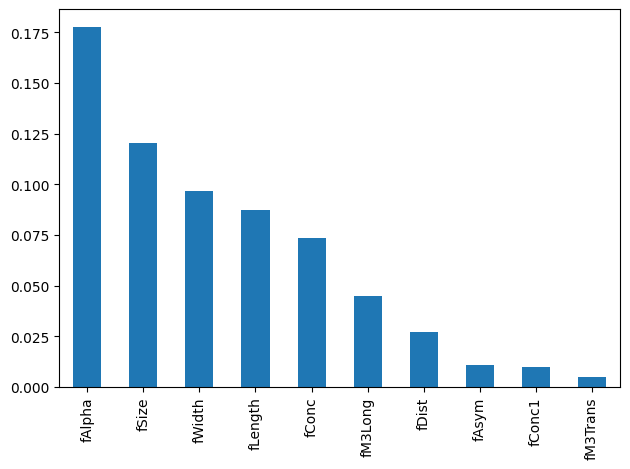

In [ ]:
import matplotlib.pyplot as plt

test_new_with_label = test_new.copy()
test_new_with_label['class'] = test_df['class'].values
#피쳐중요도를 위해서는 정답 넣어줘야해서 정답 class 라벨 추가한다.
#.values는 numpy 배열(인덱스 없이 순서대로)으로 변환(test_df['class']:인덱스 포함 상태)
# # 방법 1: .values
# df['col'].values        →  numpy 배열 (예전 방식)

# # 방법 2: .to_numpy()
# df['col'].to_numpy()    →  numpy 배열 (최신 방식)
fi = predictor.feature_importance(test_new_with_label)
# fi는 DataFrame

print(fi)

fi['importance'].plot(kind='bar')
# pandas Series(데이터프레임에서 열하나)를 막대 그래프로 그리기
plt.tight_layout()
# 레이블이 잘리지 않게 자동 여백 조정
# 이거 없으면 x축 피처 이름 잘릴 수 있음
plt.show()

# **Extreme을 쓰면 TabPFNv2, TabICL, Mitra, TabDPT, TabM 포함**

이건 tabdpt 제외 그건 너무 무거워서

In [ ]:


from autogluon.tabular import TabularPredictor

rng = np.random.default_rng(SEED)
sub_idx = rng.choice(len(train_new), 10000, replace=False)
train_new_sub = train_new.iloc[sub_idx].reset_index(drop=True)

predictor_ex3 = TabularPredictor(label='class', eval_metric='roc_auc', verbosity=1)
predictor_ex3.fit(
    train_new_sub,
    time_limit=1000,
    presets='extreme',
    excluded_model_types=['TABDPT']
)

y_pred_ex3     = predictor_ex3.predict(test_new)
y_score_ex3    = predictor_ex3.predict_proba(test_new)['g']
y_pred_ex3_bin = (y_pred_ex3 == 'g').astype(int)

evaluate("OpenFE+Extreme-TabDPT", y_test, y_pred_ex3_bin, y_score_ex3)
predictor_ex3.leaderboard(silent=True)

No path specified. Models will be saved in: "AutogluonModels/ag-20260709_050324"
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	If 'binary' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may specify problem_type as one of: ['binary', 'multiclass', 'regression', 'quantile'])
	To force training the model, specify the model hyperparameter "ag.max_memory_usage_ratio" to a larger value (currently 1.0, set to >=1.05 to avoid the error)
		To set the same value for all models, do the following when calling predictor.fit: `predictor.fit(..., ag_args_fit={"ag.max_memory_usage_ratio": VALUE})`
		Setting "ag.max_memory_usage_ratio" to values above 1 may result in out-of-memory errors. You may consider using a machine with more memory as a safer alternative.
	Not enough memory to train TabICL_c1_BAG_L1... Skipping this model.
	To force training the model, specify the model hyperp

[OpenFE+Extreme-TabDPT] Accuracy=0.9196  F1=0.9394  AUC=0.9621


,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,0.956716,roc_auc,364.386352,391.289717,0.004400,0.218981,2,True,5
1,RealTabPFN-v2_r13_BAG_L1,0.956713,roc_auc,151.324680,160.499823,151.324680,160.499823,1,True,1
2,RealTabPFN-v2_r106_BAG_L1,0.956119,roc_auc,213.057272,230.570913,213.057272,230.570913,1,True,2
3,RealTabPFN-v2_r11_BAG_L1,0.955518,roc_auc,434.147021,470.588093,434.147021,470.588093,1,True,3
4,TabM_r99_BAG_L1,0.940516,roc_auc,1.659275,99.076698,1.659275,99.076698,1,True,4


이건 기본코드들에다가 tabpfn 앙상블해본거-근데 시간 모자라서 안돌아감

In [ ]:
rng = np.random.default_rng(SEED)
sub_idx = rng.choice(len(train_new), 10000, replace=False)
train_new_sub = train_new.iloc[sub_idx].reset_index(drop=True)

predictor_mix = TabularPredictor(label='class', eval_metric='roc_auc', verbosity=2)
predictor_mix.fit(
    train_new_sub,
    time_limit=300,
    hyperparameters={
        'GBM': {},
        'CAT': {},
        'XGB': {},
        'FASTAI': {},
        'RF': {},
        'REALTABPFN-V2': {},
    }
)

y_pred_mix     = predictor_mix.predict(test_new)
y_score_mix    = predictor_mix.predict_proba(test_new)['g']
y_pred_mix_bin = (y_pred_mix == 'g').astype(int)

evaluate("OpenFE+TabPFN+Ensemble", y_test, y_pred_mix_bin, y_score_mix)
predictor_mix.leaderboard(silent=True)

No path specified. Models will be saved in: "AutogluonModels/ag-20260709_054152"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.55/14.56 GB
Total GPU Memory:   Free: 14.55 GB, Allocated: 0.01 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       6.26 GB / 12.67 GB (49.4%)
Disk Space Avail:   55.56 GB / 112.64 GB (49.3%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : New in v1.5: The state-of-the-art for tabular data. Massively better t

[OpenFE+TabPFN+Ensemble] Accuracy=0.9159  F1=0.9369  AUC=0.9620


,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,0.963195,roc_auc,21.720587,24.968162,0.000619,0.061257,2,True,7
1,RealTabPFN-v2,0.960360,roc_auc,21.685151,1.336158,21.685151,1.336158,1,True,6
2,NeuralNetFastAI,0.959477,roc_auc,0.013387,11.243632,0.013387,11.243632,1,True,4
3,CatBoost,0.957271,roc_auc,0.002039,9.747611,0.002039,9.747611,1,True,3
4,LightGBM,0.956837,roc_auc,0.019390,2.579504,0.019390,2.579504,1,True,1
5,RandomForest,0.956504,roc_auc,0.117206,14.394067,0.117206,14.394067,1,True,2
6,XGBoost,0.955440,roc_auc,0.008953,2.283453,0.008953,2.283453,1,True,5


# **OpenFe로 자동 피쳐엔지니어링(autogluon+openFe조합: 간단한것중 최강)**

In [ ]:
!pip install -q openfe

from openfe import OpenFE, transform

# class 컬럼 제거=>지금 fit(x,y)중 x를 만드는거기 때문에 class컬럼 있으면 치트지
train_df_openfe = train_df_ag.drop(columns=['class'])
test_df_openfe  = test_df_ag.drop(columns=['class'])

ofe = OpenFE()
features = ofe.fit(data=train_df_openfe, label=y_train, n_jobs=1)
# ofe.fit(
#     data=train_df_openfe,  # 피처 10개 (class 없음)
#     label=y_train,         # 정답 (0/1)
#     n_jobs=1               # CPU 코어 1개 사용=>-1은 전부 사용 (빠르지만 메모리 많이 씀)
# )

print(f"생성된 피처 수: {len(features)}")
for feature in features[:10]:
    print(feature.name, '|', [child.name for child in feature.children])
    #feature.children=>노드들의 리스트들 싹다(노드:피쳐를 담고있는 상자)
    #child in feature.children하면 그 노드 리스트 하나하나
    #child.name해야 비로소 피쳐의 리스트가 나온다.
    #openfe계산방식이 node라서 어쩔수없다.노드  →  이름 + 실제 데이터 + 계산 방법

train_new, test_new = transform(train_df_openfe, test_df_openfe, features[:10], n_jobs=1)
# transform(
#     train_df_openfe,  # 원본 train (feature 10개)
#     test_df_openfe,   # 원본 test (feature 10개)
#     features[:10],    # 추가할 피처 10개→  0번째부터 9번째까지 = 상위 10개
#     n_jobs=1          # CPU 코어 1개
# )


predictor_new = TabularPredictor(label='class', eval_metric='roc_auc', verbosity=2)
# predictor_new  →  새 AutoGluon  (피처 10+10개로 학습)
# label='class',          # 정답 컬럼 이름
#     eval_metric='roc_auc',  # 평가 지표
#     verbosity=2            # 로그 결정 2가 기본값



# # class 컬럼 다시 추가해서 학습
train_new['class'] = train_df_ag['class'].values
predictor_new.fit(train_new, time_limit=1000)
# predictor_new.fit(
#     train_new,
#     time_limit=300,
#     hyperparameters={
#         'XGB': {},   # XGBoost
#         'GBM': {},   # LightGBM
#         'CAT': {},   # CatBoost
#     }
# ) 이런식으로 모델 제한도 가능

y_pred_new     = predictor_new.predict(test_new)
y_score_new    = predictor_new.predict_proba(test_new)['g']
y_pred_new_bin = (y_pred_new == 'g').astype(int)
# ['g', 'h', 'g'] → [True, False, True]=>[1, 0, 1]# evaluate()가 숫자 받으니까
evaluate("OpenFE+AutoGluon", y_test, y_pred_new_bin, y_score_new)
predictor_new.leaderboard(silent=True)

The number of candidate features is 350
Start stage I selection.


100%|██████████| 4/4 [00:06<00:00,  1.61s/it]


56 same features have been deleted.
Meet early-stopping in successive feature-wise halving.


100%|██████████| 4/4 [00:15<00:00,  3.98s/it]


The number of remaining candidate features is 291
Start stage II selection.


100%|██████████| 4/4 [00:03<00:00,  1.31it/s]


Finish data processing.
생성된 피처 수: 291
* | ['fLength', 'fAlpha']
freq | ['fSize']
+ | ['fSize', 'fConc']
/ | ['fWidth', 'fSize']
/ | ['fConc', 'fConc1']
+ | ['fLength', 'fAlpha']
* | ['fAlpha', 'fDist']
* | ['fSize', 'fConc']
* | ['fWidth', 'fConc']
- | ['fLength', 'fWidth']


No path specified. Models will be saved in: "AutogluonModels/ag-20260709_033008"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.55/14.56 GB
Total GPU Memory:   Free: 14.55 GB, Allocated: 0.01 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       5.94 GB / 12.67 GB (46.9%)
Disk Space Avail:   57.15 GB / 112.64 GB (50.7%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : New in v1.5: The state-of-the-art for tabular data. Massively better t

[OpenFE+AutoGluon] Accuracy=0.9164  F1=0.9370  AUC=0.9633


,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,0.961501,roc_auc,0.290978,83.139225,0.000689,0.114502,2,True,12
1,LightGBMXT,0.959532,roc_auc,0.065287,3.212333,0.065287,3.212333,1,True,1
2,NeuralNetFastAI,0.957144,roc_auc,0.021677,15.749831,0.021677,15.749831,1,True,8
3,XGBoost,0.957038,roc_auc,0.026491,2.376012,0.026491,2.376012,1,True,9
4,NeuralNetTorch,0.956720,roc_auc,0.020427,36.973391,0.020427,36.973391,1,True,10
5,LightGBM,0.956617,roc_auc,0.037778,2.396146,0.037778,2.396146,1,True,2
6,CatBoost,0.956034,roc_auc,0.002211,9.183423,0.002211,9.183423,1,True,5
7,LightGBMLarge,0.955117,roc_auc,0.025898,3.724648,0.025898,3.724648,1,True,11
8,RandomForestGini,0.954090,roc_auc,0.118628,22.317010,0.118628,22.317010,1,True,3
9,RandomForestEntr,0.953968,roc_auc,0.107943,25.845444,0.107943,25.845444,1,True,4


# Optuna로 모델은 내가 지정하고 파라미터를 자동탐색해보자(AutoGluon  →  모델 선택 + 파라미터 둘 다 자동)

In [ ]:
import optuna
from sklearn.model_selection import cross_val_score
# corss_val_score:교차 검증 점수
# = 데이터를 여러 번 나눠서 평균 점수 내기
from xgboost import XGBClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)
# set_verbosity  →  말 많음의 정도를 설정해줘
# optuna.logging.WARNING  →  레벨 warning 이상만 보여줘=>info ,debug출력x,
# warning,error,critical레벨만 출력

# OpenFE 피처 포함된 X 만들기
X_new = train_new.drop(columns=['class']).to_numpy()

def objective(trial):
    params = {
        'n_estimators': 500,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 5.0),
        'tree_method': 'hist',
        'random_state': SEED,
        'n_jobs': -1,
    }
    model = XGBClassifier(**params)
    # **params = 딕셔너리를 키워드 인자로 풀어서 넣기

    scores = cross_val_score(model, X_new, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)
# # Optuna가 내부적으로:
# for i in range(50):
#     trial = Trial()  # 새 trial 객체 만들어서
#     result = objective(trial)  # objective 함수 호출
#     # result = scores.mean()
#     # 이 결과 보고 다음 파라미터 방향 결정

print("최적 파라미터:", study.best_params)
print("최적 AUC:", study.best_value)

최적 파라미터: {'learning_rate': 0.01417627144658762, 'max_depth': 9, 'subsample': 0.7342376230020635, 'colsample_bytree': 0.6173823430402052, 'reg_lambda': 1.9542410617223074}
최적 AUC: 0.9557233499327822


In [ ]:
predictor.info()['model_info']['WeightedEnsemble_L2']['children_info']['S1F1']['model_weights']

{'LightGBMXT': np.float64(0.13636363636363638),
 'CatBoost': np.float64(0.27272727272727276),
 'ExtraTreesGini': np.float64(0.09090909090909093),
 'NeuralNetFastAI': np.float64(0.40909090909090917),
 'XGBoost': np.float64(0.04545454545454546),
 'NeuralNetTorch': np.float64(0.04545454545454546)}

In [ ]:
params_fastai = predictor.info()['model_info']['NeuralNetFastAI']['hyperparameters_fit']
params_cat    = predictor.info()['model_info']['CatBoost']['hyperparameters_fit']
params_lgbm   = predictor.info()['model_info']['LightGBMXT']['hyperparameters_fit']

print("NeuralNetFastAI:", params_fastai)
print("CatBoost:", params_cat)
print("LightGBMXT:", params_lgbm)

NeuralNetFastAI: {'epochs': 30, 'best_epoch': 29}
CatBoost: {'iterations': 940}
LightGBMXT: {'num_boost_round': 1067}


In [ ]:
# # AutoGluon이 찾은 값 주변을 Optuna로 탐색
# def objective(trial):
#     params = {
#         'CAT': {
#             'iterations': trial.suggest_int('iterations', 500, 1500),  # 940 주변
#             'depth': trial.suggest_int('depth', 4, 10),
#             'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
#         }
#     }
#     predictor_trial = TabularPredictor(label='class', eval_metric='roc_auc', verbosity=0)
#     predictor_trial.fit(train_df_ag, time_limit=60, hyperparameters=params)
#     return predictor_trial.leaderboard(silent=True)['score_val'].max()

In [ ]:
submission = pd.DataFrame({
    'id': test_df.index,
    'prediction': y_score_ag  # 확률값
})
submission.to_csv('submission.csv', index=False)
# test_df.index → 각 샘플의 고유 번호
# index=True 면:
#    id  prediction
# 0   3    0.923   ← 앞에 불필요한 번호 추가됨

# index=False 면:
#  id  prediction
#   3    0.923    ← 깔끔

## 2. Logistic Regression

가장 기본적인 baseline. **선형 결정경계**만 학습할 수 있지만, 표형식 데이터에서는
의외로 강력한 출발점입니다. one-hot encoding + standard scaling을 거친 입력을 사용합니다.


In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,           # 규제 강도의 역수
    solver="lbfgs",
    random_state=SEED,
)
lr_model.fit(X_train_lin, y_train)

y_pred_lr  = lr_model.predict(X_test_lin)
y_score_lr = lr_model.predict_proba(X_test_lin)[:, 1]
# :   → 모든 행
# 1   → 1번 열만

evaluate("LogisticRegression", y_test, y_pred_lr, y_score_lr)


[LogisticRegression] Accuracy=0.7836  F1=0.8439  AUC=0.8313


## 3. Decision Tree

비선형 결정경계를 만들 수 있는 가장 단순한 모델. `max_depth`로 모델 복잡도를 조절합니다.


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=8,           # 너무 깊으면 과적합
    min_samples_leaf=20,
    random_state=SEED,
)
dt_model.fit(X_train_tree, y_train)

y_pred_dt  = dt_model.predict(X_test_tree)
y_score_dt = dt_model.predict_proba(X_test_tree)[:, 1]
evaluate("DecisionTree", y_test, y_pred_dt, y_score_dt)


[DecisionTree] Accuracy=0.8496  F1=0.8891  AUC=0.8866


In [ ]:
!pip install -q "tabpfn==2.0.9"
from tabpfn import TabPFNClassifier
import numpy as np

rng = np.random.default_rng(SEED)
# 재현 가능한 랜덤 생성기 만들기

# 옛날 방식
# np.random.seed(SEED),sub_idx = np.random.choice(15216, 10000, replace=False)


N_TABPFN = 10_000
# TabPFN 권장 범위에 맞춰 10,000개로 샘플링
# 10_000 = 10000  # 파이썬에서 _ 는 가독성용 구분자
sub_idx = rng.choice(len(X_train_tree), N_TABPFN, replace=False)
#len(X_train_tree)  = 15216  ← 행 수 = 샘플 수
# 15216개 중에서 10000개를 랜덤으로 선택
# replace=False → 중복 없이 선택(비복원)
# → sub_idx = [3, 1, 5, 0, ...]  10000개 인덱스

X_tr_pfn = X_train_tree[sub_idx]
# TabPFN이 트리처럼 스케일 무관=>standardScaler 전에거 사용
# sub_idx에 해당하는 행만 꺼내기
# (15216, 10) → (10000, 10)
y_tr_pfn = y_train[sub_idx]
# (15216,) → (10000,)
tabpfn = TabPFNClassifier(device=device.type, ignore_pretraining_limits=False)
ignore_pretraining_limits=False
# device       = torch.device("cuda")  # torch device 객체
# cuda:NVIDIA GPU에서 병렬 연산하는 기술
# device.type  = "cuda"                # 문자열로 꺼냄
# → 권장 범위 넘으면 경고 출력
tabpfn.fit(X_tr_pfn, y_tr_pfn)
# TabPFN은 학습이 없어
# fit = 데이터를 메모리에 올려두는 것=>예측할때 데이터 샘플 10000개를 참고지로 쓸수 있게 설정하는것뿐
# XGBoost처럼 반복 학습 안 함

y_pred_pfn  = tabpfn.predict(X_test_tree)
y_score_pfn = tabpfn.predict_proba(X_test_tree)[:, 1]
evaluate(f"TabPFN ({N_TABPFN} train)", y_test, y_pred_pfn, y_score_pfn)
#f string name으로 들어가는거다

[TabPFN (10000 train)] Accuracy=0.8912  F1=0.9193  AUC=0.9452


## 4. XGBoost

**Gradient Boosted Trees**의 대표적 구현체. 표형식 데이터에서 오랫동안 사실상 SOTA였고,
여전히 강력한 baseline입니다. 학습 중 validation 성능을 모니터링해 **early stopping**을 사용합니다.


In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# early stopping을 위해 train의 일부를 validation으로 분리
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_tree, y_train, test_size=0.2, random_state=SEED, stratify=y_train
)

xgb_model = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    eval_metric="auc",
    early_stopping_rounds=50,
    tree_method="hist",
    random_state=SEED,
    n_jobs=-1,
)
xgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
#val_set=[(X_val, y_val)]는 모의고사,verbose=False는 내부계산과정 안보이겠다
print("최적 반복수 :", xgb_model.best_iteration)

y_pred_xgb  = xgb_model.predict(X_test_tree)
y_score_xgb = xgb_model.predict_proba(X_test_tree)[:, 1]
evaluate("XGBoost", y_test, y_pred_xgb, y_score_xgb)


최적 반복수 : 332
[XGBoost] Accuracy=0.8872  F1=0.9156  AUC=0.9408


In [ ]:
!pip install -q optuna
import optuna
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': 500,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0),
        'tree_method': 'hist',
        'random_state': SEED,
        'n_jobs': -1,
    }
    model = XGBClassifier(**params)
    scores = cross_val_score(
        model, X_train_tree, y_train,
        cv=5, scoring='roc_auc', n_jobs=-1
    )
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("최적 파라미터:", study.best_params)
print("최적 AUC:", study.best_value)
# 최적 파라미터로 최종 모델 학습
best_params = study.best_params
best_params.update({
    'n_estimators': 2000,
    'early_stopping_rounds': 50,
    'eval_metric': 'auc',
    'tree_method': 'hist',
    'random_state': SEED,
    'n_jobs': -1,
})

xgb_model = XGBClassifier(**best_params)
xgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

y_pred_xgb  = xgb_model.predict(X_test_tree)
y_score_xgb = xgb_model.predict_proba(X_test_tree)[:, 1]
evaluate("XGBoost+Optuna+CV", y_test, y_pred_xgb, y_score_xgb)

[W 2026-07-08 07:03:44,269] Trial 24 failed with parameters: {'learning_rate': 0.048631717483615666, 'max_depth': 8, 'subsample': 0.9904305422428396, 'colsample_bytree': 0.8527708574842979, 'reg_lambda': 8.905098974483142} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_680/641754415.py", line 20, in objective
    scores = cross_val_score(
             ^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 684, in cross_val_score
    cv_results = cross_validate(
                 ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-pa

KeyboardInterrupt: 

In [ ]:
# 두 모델 확률 평균
y_score_ensemble = (y_score_xgb + y_score_pfn) / 2

# 0.5 기준으로 클래스 결정
y_pred_ensemble = (y_score_ensemble > 0.5).astype(int)

evaluate("XGBoost+TabPFN 앙상블", y_test, y_pred_ensemble, y_score_ensemble)

## 5. Deep Architecture — TabM (간소화 버전)

**TabM** (Gorishniy et al., ICLR 2025) 은 **여러 개의 MLP를 효율적으로 앙상블**하는
최신 tabular 딥러닝 모델입니다. 핵심 아이디어는:

- *k*개의 MLP를 따로 학습하는 대신, **공유되는 weight matrix**에 각 멤버별
  **저랭크(scale) 파라미터**(α, β)를 곱해 사실상 *k*개의 다른 모델을 동시에 학습.
- 메모리/계산 비용은 한 MLP에 가깝지만 앙상블 효과를 얻을 수 있음.

여기서는 강의용으로 **간소화한 구현**을 PyTorch로 직접 작성합니다.
공식 구현은 [yandex-research/tabm](https://github.com/yandex-research/tabm) 에서 확인할 수 있습니다.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# 입력 차원, 텐서 변환
INPUT_DIM = X_train_lin.shape[1]
X_tr_t = torch.tensor(np.asarray(X_train_lin), dtype=torch.float32)
y_tr_t = torch.tensor(y_train, dtype=torch.long)
X_te_t = torch.tensor(np.asarray(X_test_lin),  dtype=torch.float32)
y_te_t = torch.tensor(y_test,  dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=512, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_te_t, y_te_t), batch_size=1024, shuffle=False)

print("INPUT_DIM =", INPUT_DIM)


In [ ]:
class BatchEnsembleLinear(nn.Module):
  #nn.Module을 상속받으면 layer가 된다. BatchEnsembleLinear(10,128,8)=>layer1
    # """TabM의 핵심 모듈.

    # 공유 weight W (out, in) 하나에 대해,
    # 각 멤버 k마다 입력 측 스케일 r_k와 출력 측 스케일 s_k를 곱해
    # 실질적으로 W_k = diag(s_k) @ W @ diag(r_k) 형태의 서로 다른 weight를 흉내냅니다.

    # 입력 x: (K, B, in)
    # 출력 y: (K, B, out)

    def __init__(self, in_features, out_features, k):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features
        self.k = k
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        #weight가 공유되는 가중치
        self.bias   = nn.Parameter(torch.zeros(k, out_features))
      #  """ # 멤버별 scale (r, s)
      #   #nn.Parameter => pytorch가 자동으로 gradient 계산해서 업뎃해줌
      #   #r은 입력값 feature중 무엇을 중요하게 볼지, s는 출력할때 어떤 뉴런을 중요시할지
      #   =>반복되면 서로 같은방향작용"""
        self.r = nn.Parameter(torch.randn(k, in_features) * 0.5 + 1.0)
        self.s = nn.Parameter(torch.randn(k, out_features) * 0.5 + 1.0)
        nn.init.kaiming_uniform_(self.weight, a=5 ** 0.5)
        # 카이밍 표준화=> weight값을 조절해서 순전파하다가 값이 터지거나 소멸되지 않도록
        #5**0.5 5의 0.5제곱,루트5

    def forward(self, x):

        x = x * self.r.unsqueeze(1)
        #unsqueeze(1)=>1의 인덱스 위치에 차원추가(숫자는1로)
        # (8, 512, 10)형태
        x = x @ self.weight.t()
        #.t()는 행렬 뒤집기, @행렬곱계산을 위해서
        # (8, 512, 10) @ (10, 128) = (8, 512, 128)형태로 변환

        x = x * self.s.unsqueeze(1) + self.bias.unsqueeze(1)
         # 출력에 s, bias 적용
        return x


class TabM(nn.Module):
    # """간소화된 TabM.

    # - K개의 멤버(MLP)를 BatchEnsembleLinear로 동시에 학습
    # - 최종 예측은 K개의 logits를 평균
    # """
    def __init__(self, in_dim, hidden=128, depth=3, num_classes=2, k=8, dropout=0.1):
        super().__init__()
        self.k = k
        dims = [in_dim] + [hidden] * depth
        self.layers = nn.ModuleList([
            BatchEnsembleLinear(dims[i], dims[i+1], k) for i in range(depth)
        ])
        #nn.ModuleList([layer1,layer2,layer3])로 적어놔야 이 안에 학습할 파라미터 있다고 인지된다.
        #일반 리스트로는 x
        self.head = BatchEnsembleLinear(hidden, num_classes, k)
        # 이렇게 저장해놓고 self.head(x)하면 self.head.foreward(x)가 실행된다.
        self.dropout = nn.Dropout(dropout)
        # 작동시마다 0.1비율만큼 뉴런을꺼서 다양성을 확보한다 과적합 방지

    def forward(self, x):
        # x: (B, in) -> (K, B, in)
        x = x.unsqueeze(0).expand(self.k, -1, -1)
        #1을 k로 확장, -1은 나머지는 그대로 두란 의미=>512개 샘플을 k개 멤버에게 복사해서 나눠주는거
        #x = xb = (512, 10)=>(8, 512, 10)
#         (8,    512,   10)
#         ↑      ↑     ↑
#         멤버   샘플(행)   feature(열)

        for layer in self.layers:
            x = layer(x)
            x = F.relu(x)
            x = self.dropout(x)
        logits = self.head(x)       #(8, 512, 128)=>(8, 512, 2)로 압축
        return logits

    def predict_logits(self, x):
        # """K개 멤버의 평균 logits."""
        logits = self.forward(x)
        #이건 8개 멤버 전부 각각 가지고 있는상태
        return logits.mean(dim=0)
        #dim=0(멤버방향k)로 평균 반환
      #  """ logits = (3, 2, 2)=> (2,2)"""



In [ ]:
# 학습 루프
tabm = TabM(in_dim=INPUT_DIM, hidden=192, depth=3, num_classes=2, k=8, dropout=0.1).to(device)
optimizer = torch.optim.AdamW(tabm.parameters(), lr=3e-4, weight_decay=1e-5)
#tabm.parameters()ㅣTabM 안에 있는 모든 학습할 파라미터 목록을 반환
#3e-4  =  3 × 10^-4 = 0.0003
# #AdamW:학습률 자동으로 조정하는 optimizer,lr=3e-4=>학습률,
#weight_decay=1e-5=>L2규제 과적합 방지(가중치가 너무 커지면 자동으로 패널티줌)
ce_loss = nn.CrossEntropyLoss()
#표준 손실함수, 예측이 정답에서 멀수록 loss 커짐
EPOCHS = 20
#20 epoch = 15216개 × 20번 = 304,320번 샘플  학습(20회 반복학습)
for epoch in range(1, EPOCHS + 1):

    tabm.train()
    #모델을 학습모드로 전환=>dropout작동/평가모드(tabm.eval())는 dropout꺼짐
    total, n = 0.0, 0
    #두변수를 각각0.0,0으로 초기화
    for xb, yb in train_loader:
      # xb:(512,10),yb:(512,)
      #=>train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=512, shuffle=True)
      #X_tr_t:(15216, 10)/y_tr_t  →  (15216,)
        xb, yb = xb.to(device), yb.to(device)
        #cpu->gpu로 이동
        logits = tabm(xb)
        # tabm(xb) = TabM.forward(xb) 자동 실행
        # xb: (512, 10)  ← 배치 feature
        # 내부에서:
        # unsqueeze+expand → (8, 512, 10)
        # layer1,2,3 통과 → (8, 512, 128)
        # head 통과       → (8, 512, 2)=>logits [2.3, -1.1]  ← 그냥 선형 계산 결과 = 날것의 점수

        # 각 멤버를 동일 라벨에 대해 학습 → K번 평균 loss
        loss = ce_loss(logits.reshape(-1, 2), yb.repeat(tabm.k))
# ce_loss를 통과하면 [2.3, -1.1]  → softmax → [0.97, 0.03]로 변환
# 정답: 1 (gamma)
        # (8, 512, 2) → (4096, 2)=> 8개 멤버 × 512샘플을 한 줄로 펼침
        #reshape(-1, 2) = "열은 2개로 고정하고, 행은 알아서 맞춰줘"
#         yb = [1, 0, 1, ...]  # 512개 정답
# yb.repeat(8) = [1, 0, 1, ..., 1, 0, 1, ...]  # 4096개
# #               ↑ 512개    ↑ 512개 × 8번
# 왜 8번 반복하냐
# 멤버1의 512개 샘플 → 정답 512개 필요
# 멤버2의 512개 샘플 → 정답 512개 필요
# ...
# 멤버8의 512개 샘플 → 정답 512개 필요
# → 총 4096개 정답 필요
# → yb를 8번 반복
        optimizer.zero_grad()
        #loss계산후 gradient 초기화로 준비
        loss.backward()
        #역전파로 gradient 계산
        optimizer.step()
        #저장된 gradient를 사용해 w,r,s 업데이트
        total += loss.item() * xb.size(0)
        #loss.item() loss값을 파이썬 순수 숫자로 가져온다. loss.item() = 0.4312,gradient 추적 정보 없음
        #xb.size(0) batch 크기 (512)
        n     += xb.size(0)
         # 배치 샘플 수 누적, 30번 반복하면 n = 15216
    if epoch % 4 == 0 or epoch == 1:
        print(f"epoch {epoch:02d}  train_loss={total/n:.4f}")# f string 문법
#         epoch:02d    →  숫자 2자리로 표시 (01, 04, 08...)
# total/n      →  전체 샘플 기준 평균 loss
# :.4f         →  소수점 4자리


In [ ]:
# 평가
tabm.eval()#dropout 꺼짐=>뉴런 전부 켜진 상태로 예측해야지 안그러면 매번 다른결과 나오겠지
all_logits, all_y = [], []
# all_logits = []  # 배치별 logits 모아두는 리스트
# all_y      = []  # 배치별 정답 모아두는 리스트
with torch.no_grad():
  # gradient 계산 끄는 거,예측할땐 필요없지
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = tabm.predict_logits(xb)
        # forward 실행 → (8, B, 2)

        all_logits.append(logits.cpu())
        # .cpu() → GPU에 있는 tensor를 CPU로 이동
# 나중에 numpy로 변환할 때 CPU에 있어야 함
        all_y.append(yb)
logits = torch.cat(all_logits)
# 리스트에 쌓인 배치들을 하나로 합치기

# all_logits = [(512, 2), (512, 2), ..., (216, 2)]
# torch.cat  → (3804, 2)  ← 전체 test 샘플
probs  = torch.softmax(logits, dim=-1)[:, 1].numpy()
# logits: (3804, 2)  날것의 점수
# [[0.97, 0.03],  ← hadron 97%,gamma 3%
#  [0.23, 0.77],  ← hadron 23%,gamma 77%
# softmax → 확률로 변환 (합이 1)

# [:, 1] → gamma 확률만 꺼내기
# [0.03, 0.77, ...]  (3804개)

# .numpy()
# torch tensor → numpy 배열로 변환
# evaluate() 함수가 numpy를 받으니까
preds  = logits.argmax(dim=-1).numpy()
#          dim=1 →
#         0번열  1번열
# dim=0  [2.3,  -1.1]   ← 행0
#   ↓    [-0.5,  0.8]   ← 행1
#        [1.2,  -0.3]   ← 행2

# dim=-1 방향 = 좌우 방향으로 비교
#argmax → 각 행에서 2개 값 중 최대 인덱스

# 행0: 2.3, -1.1 중 최대 = 2.3 → 0번열 → 0
# 행1: -0.5, 0.8 중 최대 = 0.8 → 1번열 → 1
# 행2: 1.2, -0.3 중 최대 = 1.2 → 0번열 → 0
# 결과: [0, 1, 0]  ← 행 수만큼
evaluate("TabM", y_test, preds, probs)


## 6. LLM 실험 — 작은 오픈 모델로 분류

LLM을 표형식 데이터에 적용하는 가장 단순한 방법은:

1. **직렬화 (serialization)** — 각 행을 자연어 문장으로 변환
   예) `major axis length (fLength)=28.797, minor axis width (fWidth)=16.002, ... → gamma or hadron?`
2. **프롬프트** — 라벨이 있는 예시 몇 개(few-shot)와 함께 입력
3. **출력 디코딩** — 모델이 생성한 `gamma` / `hadron` 토큰을 파싱

여기서는 **Qwen2.5-0.5B-Instruct** (작고 라이선스 친화적) 를 사용합니다.
큰 LLM이 아니므로 정확도는 baseline 수준이며, *방법론* 자체를 체험하는 것이 목적입니다.
특히 MAGIC은 feature가 추상적 물리량이라 작은 LLM이 도메인 지식을 활용하기 어렵습니다 —
모델 크기를 키운 결과는 Section 9에서 비교합니다.

⚠️ 추론이 상대적으로 느리므로 **테스트셋 중 200개만 샘플링**해서 평가합니다.


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"
# Qwen      →  알리바바가 만든 오픈소스LLM 시리즈
# 2.5       →  버전
# 0.5B      →  파라미터 수 5억개 (작은 모델)
# Instruct  →  지시사항 따르도록 파인튜닝된 버전
# AutoTokenizer         →  텍스트를 숫자로 변환하는 도구
# AutoModelForCausalLM  →  텍스트 생성 LLM 모델
tok = AutoTokenizer.from_pretrained(MODEL_ID)
# 허깅페이스에서 Qwen 토크나이저 다운로드
llm = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
).to(device)
# GPU (cuda)  →  float16  (메모리 절반, 속도 빠름)
# CPU         →  float32  (CPU는 float16 지원 약함)
llm.eval()
print("모델 로드 완료:", MODEL_ID)


In [ ]:
# 1) 행 → 자연어 직렬화 함수
# 읽기 쉽게 각 feature에 짧은 한 줄 설명을 곁들입니다.=>이걸 serialize_row함수가 참고해서 문장만들어서 llm에게 넘겨줌
FEATURE_DESC = {
    "fLength":  "major axis length",
    "fWidth":   "minor axis width",
    "fSize":    "log of pixel sum",
    "fConc":    "top-2 pixel ratio",
    "fConc1":   "top-1 pixel ratio",
    "fAsym":    "asymmetry along major axis",
    "fM3Long":  "3rd moment along major axis",
    "fM3Trans": "3rd moment along minor axis",
    "fAlpha":   "angle of major axis vs origin",
    "fDist":    "distance from origin",
}

def serialize_row(row: pd.Series) -> str:
  #pd.Series:입력 타입 힌트, ->str 출력타입 힌트
  #Series: pandas의1차원 배열:행하나 또는 열하나로이루어진 배열<=>df(DataFrame)는 2차원 배열
    parts = [f"{FEATURE_DESC[c]} ({c})={row[c]:.3f}" for c in NUM_COLS]
    #list compreension: expression for c in NUM_COLS=> NUM_COLS의 각 컬럼명(c)마다 expression 실행
    # 결과를 리스트로 만들어줌
#     parts = [
#     "major axis length (fLength)=28.797",
#     "minor axis width (fWidth)=16.002",
#     "log of pixel sum (fSize)=2.645",
#     ...
# ]  ← 10개짜리 리스트
    return ", ".join(parts)
    #.join(parts): ["A", "B", "C"] → "A, B, C"

# 예시 출력
print(serialize_row(train_df.iloc[0]))
# train_df.iloc[0]  →  28.7  (첫 번째 위치)
# train_df.loc[0]   →  28.7  (인덱스 0)=> 섞으면 인덱스 0이 뒤로 갈수도 있으니까, 아무튼 둘다 리스트 아니고 df에서 행꺼내는 방법


In [ ]:
# 2) few-shot 예시 구성 — 양/음 클래스에서 각각 4개씩
rng = np.random.default_rng(SEED)
pos_pool = train_df.index[train_df[TARGET] == "g"]
# TARGET="class"=> 우리가 만든 정답 컬럼 이름이 class
# gamma 샘플들의 인덱스 목록
neg_pool = train_df.index[train_df[TARGET] == "h"]
pos_idx = rng.choice(pos_pool, 4, replace=False)
neg_idx = rng.choice(neg_pool, 4, replace=False)
fewshot_idx = np.concatenate([pos_idx, neg_idx])
# pos_idx = [3, 7, 12, 45]   # gamma 4개 인덱스
# neg_idx = [2, 9, 18, 33]   # hadron 4개 인덱스
# [3, 7, 12, 45, 2, 9, 18, 33]  ← 8개 합치기

rng.shuffle(fewshot_idx)
# [9, 3, 18, 7, 45, 2, 33, 12]  ← 랜덤으로 섞음

INSTRUCTION = (
    "You are a classifier for the MAGIC Cherenkov telescope. "
    "Given numerical shower-image features (geometry, asymmetry, moments, angle), "
    "predict whether the event is a gamma-ray signal or a hadron background. "
    "Answer with exactly one word: gamma or hadron."
)
# llm에게 주는 프롬프트

LABEL_TEXT = {"g": "gamma", "h": "hadron"}
# "g" → "gamma"  LLM이 읽을 수 있는 단어로 변환

def build_prompt(test_row: pd.Series) -> str:
    msgs = [{"role": "system", "content": INSTRUCTION}]
    for i in fewshot_idx:
        ex = train_df.loc[i]
        msgs.append({"role": "user",      "content": serialize_row(ex)})
        msgs.append({"role": "assistant", "content": LABEL_TEXT[ex[TARGET]]})
        # serialize_row(ex)
        # = "major axis length (fLength)=23.800, minor axis width (fWidth)=9.500, ..."

        # LABEL_TEXT[ex["class"]]
        # = LABEL_TEXT["h"]
        # = "hadron"

        # msgs에 추가:
        #   {"role": "user", "content": "major axis length (fLength)=23.800, minor axis width (fWidth)=9.500, ..."}
        #   {"role": "assistant", "content": "hadron"}
    msgs.append({"role": "user", "content": serialize_row(test_row)})
    # 실제 분류할 샘플 추가
    # assistant 없음 → LLM이 채워야 함
    return tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    # tok = AutoTokenizer.from_pretrained(MODEL_ID)
    #apply_chat_template: msgs 리스트를 Qwen이 읽을 수 있는 특정 포맷 문자열로 변환
    # tokenize=False=>문자열로 반환, True면 숫자 토큰으로 반환
    # add_generation_prompt=True여야 llm이 어디서 답할지 신호 줌.


print(build_prompt(test_df.iloc[0])[:800], "...")
# test_df.iloc[0]:test 데이터 첫 번째 행 (pd.Series)
# build_prompt(test_df.iloc[0])=>그 행으로 프롬프트 전체 생성
# [:800]=> 프롬프트의 앞 800자만 잘라서
# test_df.iloc[0]
# → test_df의 첫 번째 행 하나
# → pd.Series 형태

# fLength    75.136
# fWidth     30.920
# fSize       3.161
# fConc       0.317
# ...
# class       g


In [ ]:
# 3) 200개 샘플에 대해서만 분류
N_LLM_SAMPLES = 200
sample_idx = rng.choice(len(test_df), N_LLM_SAMPLES, replace=False)
# LLM은 샘플 하나당 추론이 느림 3804개 전부 하면 수십 분 200개만 해서 빠르게 체험

def first_token_id(text):
    return tok(text, add_special_tokens=False).input_ids[0]
# 텍스트를 토큰으로 변환
# 토크나이저가반환하는 딕셔너리:{'input_ids': [12345], 'attention_mask': [1]}=>딕셔너리 중 인덱스 0인 토큰id 반환:12345
POS_IDS = list({first_token_id(t) for t in ["gamma", " gamma", "Gamma", " Gamma"]})
# tok("gamma").input_ids   = [12345] tok(" gamma").input_ids  = [67890]  ← 완전히 다른 ID=> 이걸 방지하기위해서
# {}부분은 set comprehension<=>[]인 리스트 컴프리헨션=>중복제거를 위해 set쓰고 다시 list로 만든다.
NEG_IDS = list({first_token_id(t) for t in ["hadron", " hadron", "Hadron", " Hadron"]})
# # 각 변형마다 토큰 ID 계산
# first_token_id("gamma")   = 12345
# first_token_id(" gamma")  = 12345  ← 같을 수도
# first_token_id("Gamma")   = 23456
# first_token_id(" Gamma")  = 23456  ← 같을 수도

# # set으로 중복 제거
# {12345, 23456}  ← 중복 사라짐
llm_preds, llm_scores = [], []
# llm_preds  = []  # 예측 클래스 모아두는 리스트 (0 또는 1)
# llm_scores = []  # gamma 점수 모아두는 리스트 (AUC용)
with torch.no_grad():
      # 이 블록 안에서 gradient 추적 안 함(학습이 아닌 예측하는거니까)
    for j, idx in enumerate(sample_idx):
        row = test_df.iloc[idx]
        prompt = build_prompt(row)
        inputs = tok(prompt, return_tensors="pt").to(device)
        # return_tensors="pt"→ 결과를 PyTorch tensor로 반환(pytorch의 pt)

        out = llm(**inputs)
        # 딕셔너리 통째로("":) 넣는 것 vs 함수인자(=) 쌍으로 풀어서 넣는 것
        # inputs = {
        #     "input_ids": tensor([[15, 847, ...]]),
        #     "attention_mask": tensor([[1, 1, ...]])
        # }

        # llm(**inputs)
        # # = llm(input_ids=tensor([[15, 847, ...]]),
        # #        attention_mask=tensor([[1, 1, ...]]))
        # out.logits.shape = (1, 500, 150000)
        #                    ↑   ↑     ↑
        #                  배치 위치  어휘크기
        next_logits = out.logits[0, -1]
        # 0번째 샘플의 마지막 위치의 점수 리스트(이 llm이알고 있는단어가 15만개라서 리스트 크기는 15만
        # shape: (150000,)


        pos_score = torch.logsumexp(next_logits[POS_IDS], dim=0).item()
        # POS_IDS = gamma 관련 토큰들의 ID 목록
#         # 리스트로 인덱싱 (Fancy Indexing:numpy,torch 전용 문법)
#           next_logits[[12345, 23456]]
#         → 12345번, 23456번 위치 둘 다 반환
#         → [2.1, 2.3]  ← 리스트 반환
# logsumexp([a, b]) = log(e^a + e^b),e^logit = 우리가 아는확률
# dim=0 = 행 방향으로 합산 → [결과1, 결과2]
        neg_score = torch.logsumexp(next_logits[NEG_IDS], dim=0).item()
        llm_preds.append(int(pos_score > neg_score))

        llm_scores.append(pos_score - neg_score)
        # pos_score - neg_score = 1.15  # 양수 → gamma 1.15만큼 확신=>AUC 계산을 위한 score (logit margin)
        if (j + 1) % 50 == 0:
            print(f"  진행: {j+1}/{N_LLM_SAMPLES}")
            # =0~48   → 출력 없음
            # j=49     → (49+1)=50, 50%50=0  → "진행: 50/200"
            # j=99     → 100%50=0            → "진행: 100/200"
            # j=149    →                     → "진행: 150/200"
            # j=199    →                     → "진행: 200/200"

y_sub = y_test[sample_idx]
evaluate("LLM (Qwen2.5-0.5B, 200 samples)", y_sub,
         np.array(llm_preds), np.array(llm_scores))
# y_test      = [1, 0, 1, ...]  # 3804개 전체 정답
# sample_idx  = [3, 7, 18, ...]  # 선택된 200개 인덱스

# y_test[sample_idx]
# → 200개 인덱스에 해당하는 정답만 꺼냄
# → y_sub = [1, 0, 1, ...]  # 200개
# np.array() → numpy 배열로 변환=>evaluate()가 numpy 받으니까.


## 7. TabPFN — Tabular Foundation Model

**TabPFN v2** (Hollmann et al., Nature 2025) 은 사전학습된 transformer 하나가
**fitting 없이** 새 데이터셋을 *in-context*로 분류/회귀합니다.

특징:
- 학습 과정이 사실상 없음 (`fit`은 데이터를 메모리에 올리는 정도)
- 작은~중간 규모 데이터셋(≤10K samples, ≤500 features)에서 매우 강력
- 추론 시 GPU가 있으면 훨씬 빠름

MAGIC 학습셋은 약 15,200개로 TabPFN 권장 범위(≤10K)를 살짝 넘으므로
**10,000개로 subsample**해 사용합니다.


In [ ]:
from tabpfn import TabPFNClassifier

# TabPFN의 권장 범위에 맞춰 학습셋 subsample
N_TABPFN = 10_000
sub_idx = rng.choice(len(X_train_tree), N_TABPFN, replace=False)

X_tr_pfn = X_train_tree[sub_idx]
y_tr_pfn = y_train[sub_idx]

tabpfn = TabPFNClassifier(device=device.type, ignore_pretraining_limits=False)
tabpfn.fit(X_tr_pfn, y_tr_pfn)

y_pred_pfn  = tabpfn.predict(X_test_tree)
y_score_pfn = tabpfn.predict_proba(X_test_tree)[:, 1]
evaluate(f"TabPFN ({N_TABPFN} train)", y_test, y_pred_pfn, y_score_pfn)


## 8. 결과 비교

지금까지 실험한 모든 모델의 정확도/F1/AUC를 한 번에 봅니다.


In [ ]:
summary = pd.DataFrame(results).T.round(4)
# result는 딕셔너리
# result={
#     "LogisticRegression": {"Accuracy": 0.78, "F1": 0.84, "AUC": 0.83},
#     "XGBoost":            {"Accuracy": 0.88, "F1": 0.91, "AUC": 0.94},
#     "TabPFN":             {"Accuracy": 0.89, "F1": 0.92, "AUC": 0.95},
#     ...
# }
# 딕셔너리[키] = 값(딕셔너리 저장방식)
# 딕셔너리를 DataFrame형식으로 바꾼뒤 T로 행과 열 전치시키고 round4로 5자리에서 반올림
summary = summary.sort_values("AUC", ascending=False)
# AUC 기준으로 내림차순 정렬
summary
# 마지막 줄에 뭐적어놓은건 알아서 출력이된다, 표현식이나 df를 의미하면 그거 결과 출력 해준다.



## 9. (추가 실험) LLM 성능 끌어올리기 — 더 큰 모델로 swap

방금 본 LLM 결과가 다른 모델보다 한참 낮은 이유는 **모델이 너무 작기 때문**입니다 (0.5B).
직렬화 방식이나 프롬프트는 그대로 두고, **모델만 키워도** 정확도가 올라갈 수 있습니다.

여기서는 **Qwen2.5-3B-Instruct** 로 바꿔 봅니다.
- fp16 으로 약 6GB → Colab T4 (16GB) 에서 사용 가능
- few-shot 예시, 직렬화, 평가 코드는 그대로 재사용

In [ ]:
# 메모리 정리 후 더 큰 모델 로드
del llm, tok
# 기존모델삭제
import gc; gc.collect()
 # 파이썬 메모리 정리(쓰레기 수거(garbage collector))
if torch.cuda.is_available():
    torch.cuda.empty_cache()
     # GPU 메모리 정리는 파이썬 별개로 torch전용함수로

BIG_MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"

tok = AutoTokenizer.from_pretrained(BIG_MODEL_ID)
llm = AutoModelForCausalLM.from_pretrained(
    BIG_MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
)
# # 기존
# .to(device)

# # 3B
# device_map="auto"=>cpu/gpu 적절히분배, 모델이 크기때문에
llm.eval()
print("모델 로드 완료:", BIG_MODEL_ID)


In [ ]:
# 같은 평가 루프를 더 큰 모델로 그대로 다시 실행
# (POS_IDS/NEG_IDS도 새 tokenizer로 다시 계산)
POS_IDS = list({first_token_id(t) for t in ["gamma", " gamma", "Gamma", " Gamma"]})
NEG_IDS = list({first_token_id(t) for t in ["hadron", " hadron", "Hadron", " Hadron"]})

llm_preds_big, llm_scores_big = [], []
with torch.no_grad():
    for j, idx in enumerate(sample_idx):
        row = test_df.iloc[idx]
        prompt = build_prompt(row)
        inputs = tok(prompt, return_tensors="pt").to(llm.device)
        # llm.device  →  모델이 실제로 올라간 device(cpu/gpu 적절분배하기로 바꿨으니까 알아야한다)

        next_logits = llm(**inputs).logits[0, -1]
        pos = torch.logsumexp(next_logits[POS_IDS], dim=0).item()
        neg = torch.logsumexp(next_logits[NEG_IDS], dim=0).item()
        llm_preds_big.append(int(pos > neg))
        llm_scores_big.append(pos - neg)
        if (j + 1) % 50 == 0:
            print(f"  진행: {j+1}/{N_LLM_SAMPLES}")

evaluate("LLM (Qwen2.5-3B, 200 samples)", y_sub,
         np.array(llm_preds_big), np.array(llm_scores_big))


## 10. (추가 실험) 모델 간 성능 차이를 더 잘 보기 — small-data 세팅

전체 데이터(~15K)에서도 MAGIC은 모델 간 차이가 어느 정도 보이지만,
**학습 데이터를 500개로 줄이면** 각 모델의 차이가 한층 또렷해집니다.

아래 셀은 빠른 모델 4종(LR, DT, XGB, TabPFN)만 500개로 다시 학습해 비교합니다.


In [ ]:
# 학습 데이터 500개로 subsample
SUBSAMPLE_N = 500
sub = rng.choice(len(X_train_tree), SUBSAMPLE_N, replace=False)

X_train_lin_small  = X_train_lin[sub]
X_train_tree_small = X_train_tree[sub]
y_train_small      = y_train[sub]

# small-data 결과만 따로 모으기
small_results = {}
def eval_small(name, y_pred, y_score):
    a = accuracy_score(y_test, y_pred)
    f = f1_score(y_test, y_pred)
    u = roc_auc_score(y_test, y_score)
    small_results[name] = {"Accuracy": a, "F1": f, "AUC": u}
    print(f"[{name}] Acc={a:.4f}  F1={f:.4f}  AUC={u:.4f}")

# --- Logistic Regression ---
m = LogisticRegression(max_iter=1000, random_state=SEED)
m.fit(X_train_lin_small, y_train_small)
eval_small("LR (n=500)",  m.predict(X_test_lin),  m.predict_proba(X_test_lin)[:, 1])

# --- Decision Tree ---
m = DecisionTreeClassifier(max_depth=8, min_samples_leaf=20, random_state=SEED)
m.fit(X_train_tree_small, y_train_small)
eval_small("DT (n=500)",  m.predict(X_test_tree), m.predict_proba(X_test_tree)[:, 1])

# --- XGBoost (early stopping 없이 단순화) ---
m = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    eval_metric="auc", tree_method="hist", random_state=SEED, n_jobs=-1,
)
m.fit(X_train_tree_small, y_train_small)
eval_small("XGB (n=500)", m.predict(X_test_tree), m.predict_proba(X_test_tree)[:, 1])

# --- TabPFN — 작은 데이터에서 특히 강력 ---
m = TabPFNClassifier(device=device.type)
m.fit(X_train_tree_small, y_train_small)
eval_small("TabPFN (n=500)", m.predict(X_test_tree), m.predict_proba(X_test_tree)[:, 1])

print()
print("=== small-data (n=500) 결과 ===")
pd.DataFrame(small_results).T.round(4).sort_values("AUC", ascending=False)


응용: `SUBSAMPLE_N` 을 100 / 500 / 2000 / 15000 으로 바꿔가며 같은 셀을 돌리면,
각 모델의 **데이터 효율(data efficiency) 곡선** 을 그릴 수 있습니다.


# 실험통


In [ ]:
!pip install -q "tabpfn==2.0.9"
from tabpfn import TabPFNClassifier
import numpy as np

rng = np.random.default_rng(SEED)

# TabPFN 권장 범위에 맞춰 10,000개로 샘플링
N_TABPFN = 10_000
sub_idx = rng.choice(len(X_train_tree), N_TABPFN, replace=False)

X_tr_pfn = X_train_tree[sub_idx]
y_tr_pfn = y_train[sub_idx]

tabpfn = TabPFNClassifier(device=device.type, ignore_pretraining_limits=False)
tabpfn.fit(X_tr_pfn, y_tr_pfn)

y_pred_pfn  = tabpfn.predict(X_test_tree)
y_score_pfn = tabpfn.predict_proba(X_test_tree)[:, 1]
evaluate(f"TabPFN ({N_TABPFN} train)", y_test, y_pred_pfn, y_score_pfn)

In [ ]:
# @title 기본 제목 텍스트
import xgboost
print(xgboost.__version__)
import sklearn
print(sklearn.__version__)
!pip show xgboost